# Solving the Traveling Salesman  Problem using Local Search

Points: 10

## The [Traveling Salesman Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem)

* __Goal:__ Find the shortest tour visiting each of $n$ cities exactly once and returning back to the starting city. Given are pairwise distances between cities, where $d_{i,j}$ is the distance from city $i$ to city $j$. 

* __State space:__ Each state represents a tour. The cities are numbered and a tour can be expressed as vector  $\pi$ with the order in which the cities are visited (a [permutation](https://en.wikipedia.org/wiki/Permutation)). That is, $\pi(1)$ is the index of the first city to visit, $\pi(2)$ the index of the second, and so on.

* __Objective function:__ Minimize the tour length. The optimization problem is to find the optimal tour $\pi^*$ through the $n$ cities and returning to the starting city:

  > minimize: $\mathrm{tourlength}(\pi) = d_{\pi(n),\pi(1)} + \sum_{i = 1}^{n-1} d_{\pi(i),\pi(i+1)}$
  > 
  > subject to: $\pi \ \text{is a valid permutation vector}$

* __Local moves:__ Exchange two cities in the order.

## Helper functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

np.set_printoptions(precision=2)
#pd.set_option('precision', 2) bản cũ sử dụng cơ bản
pd.set_option('display.precision', 2) # bản mới sử dụng

# make the results repeatable
np.random.seed(1234)

In [2]:
def random_tour(n):
    """Create a random tour"""
    
    tour = list(range(n))
    random.shuffle(tour)
    return(tour)

random_tour(10)

[1, 4, 3, 2, 8, 5, 9, 0, 7, 6]

In [3]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

def random_tsp(n):
    """
    Create a random (Euclidean) traveling salesman problem. Choose n points randomly in a 1 x 1 unit square and calulates a 
    pairwise Euclidean distance matrix.
    """
    
    pos = pd.DataFrame({
        "x" : np.random.uniform(size = n),
        "y" : np.random.uniform(size = n)
    })
    
    dist = squareform(pdist(pos))
    
    return({"pos": pos, "dist": dist})
    
tsp = random_tsp(10)

print(f"Positions:\n{tsp['pos']}")
print(f"Distance matrix:\n{pd.DataFrame(tsp['dist'])})")

Positions:
      x     y
0  0.19  0.36
1  0.62  0.50
2  0.44  0.68
3  0.79  0.71
4  0.78  0.37
5  0.27  0.56
6  0.28  0.50
7  0.80  0.01
8  0.96  0.77
9  0.88  0.88
Distance matrix:
      0     1     2     3     4     5     6     7     8     9
0  0.00  0.45  0.41  0.69  0.59  0.22  0.17  0.70  0.87  0.86
1  0.45  0.00  0.26  0.27  0.20  0.35  0.35  0.52  0.43  0.46
2  0.41  0.26  0.00  0.35  0.46  0.21  0.24  0.76  0.53  0.48
3  0.69  0.27  0.35  0.00  0.34  0.53  0.55  0.70  0.18  0.19
4  0.59  0.20  0.46  0.34  0.00  0.54  0.52  0.36  0.44  0.52
5  0.22  0.35  0.21  0.53  0.54  0.00  0.06  0.76  0.72  0.68
6  0.17  0.35  0.24  0.55  0.52  0.06  0.00  0.72  0.73  0.71
7  0.70  0.52  0.76  0.70  0.36  0.76  0.72  0.00  0.77  0.87
8  0.87  0.43  0.53  0.18  0.44  0.72  0.73  0.77  0.00  0.14
9  0.86  0.46  0.48  0.19  0.52  0.68  0.71  0.87  0.14  0.00)


In [4]:
def tour_length(tsp, tour):
    """Caclulate the length of a tour, i.e., the objective function."""
    
    # make sure tour is a Python list (not an array or a numpy.array)
    if not isinstance(tour, list): tour = tour.tolist()
    
    tl = 0
    dist = tsp["dist"]
    
    for i in range(len(tour)-1):
        tl += dist[tour[i], tour[i+1]]
    
    tl += dist[tour[-1], tour[0]]
    
    return(tl)
        
tour = random_tour(10)
tour_length(tsp, tour)

3.434015105030388

Tour length: 3.43


C:\Users\Acer\AppData\Local\Temp\ipykernel_10792\485338383.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pos_ = pos_.append(pos_.head(1))


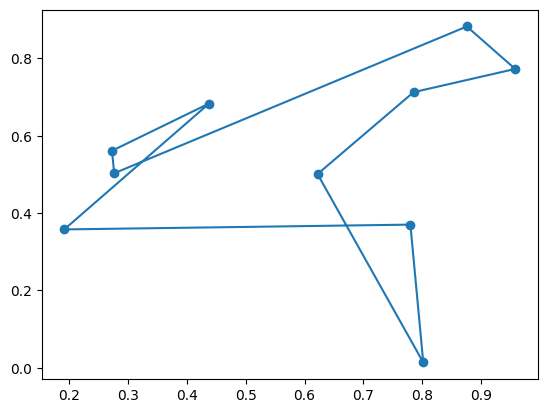

In [5]:
def show_tsp(tsp, tour = None):  
    """display the traveling salesman problem and a tour."""
    
    pos = tsp["pos"]
    
    plt.scatter(pos["x"], pos["y"])
    
    if tour is not None:
        # make sure tour is a Python list (not an array or a numpy.array)
        if not isinstance(tour, list): tour = tour.tolist()
        
        print(f"Tour length: {round(tour_length(tsp, tour), 2)}")
        
        pos_ = pos.reindex(tour)
        pos_ = pos_.append(pos_.head(1))
        plt.plot(pos_["x"], pos_["y"])
    
    plt.show()
    
show_tsp(tsp, tour)

## Use R to find a solution

Load rpy2, make sure the R [TSP package](https://CRAN.R-project.org/package=TSP) is installed and prepare the distance matrix.

In [6]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [7]:
%%R
# %load_ext rpy2.ipython

if(!"TSP" %in% rownames(installed.packages())) install.packages("TSP", repos="http://cran.us.r-project.org")
if(!"microbenchmark" %in% rownames(installed.packages())) install.packages("microbenchmark", repos="http://cran.us.r-project.org")

# d = tsp["dist"]

In [8]:
d = tsp["dist"]

Solve the TSP using [`solve_TSP`](https://www.rdocumentation.org/packages/TSP/versions/1.1-10/topics/solve_TSP) with the default heuristic. Note that 2-opt is steepest ascend hill climbing with exchanging two cities. `rep=100` means 100 random restarts.

In [9]:
%%R -i d -o tour

library("TSP")

tsp <- TSP(d)
print(tsp)

tour <- solve_TSP(tsp, rep = 100)
print(tour)

# R starts index with 1, but Python starts at 0
tour <- tour - 1L

object of class 'TSP' 
10 cities (distance 'unknown') 
object of class 'TOUR' 
result of method 'arbitrary_insertion+two_opt_rep_100' for 10 cities
tour length: 2.763574 


In addition: Warning message:
executing %dopar% sequentially: no parallel backend registered 


Tour length: 2.76


C:\Users\Acer\AppData\Local\Temp\ipykernel_10792\485338383.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pos_ = pos_.append(pos_.head(1))


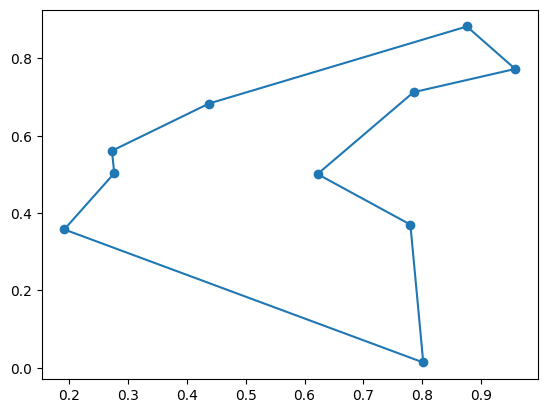

In [10]:
show_tsp(tsp, tour)

How long does it take to solve the problem 100 times?

In [11]:
%%R -i d

library("microbenchmark")

microbenchmark(tsp <- TSP(d))

Unit: microseconds
          expr   min    lq    mean median  uq   max neval
 tsp <- TSP(d) 184.5 198.2 241.903 213.65 259 624.2   100


## Steepest-ascend Hill Climbing Search [3 Points]

Calculate the objective function for all local moves (move each queen within its column) and always choose the best among all local moves.

In [ ]:
# Code goes here
import time

def steepest_ascent_tsp(tsp, max_iter=1000):
    n = tsp["dist"].shape[0]
    current_tour = random_tour(n)
    current_length = tour_length(tsp, current_tour)

    for iteration in range(max_iter):
        best_neighbor = None
        best_length = current_length

        # Duyệt tất cả các cặp (i, j) để thực hiện 2-opt
        for i in range(n):
            for j in range(i + 1, n):
                neighbor = current_tour[:]
                neighbor[i:j+1] = reversed(neighbor[i:j+1])
                neighbor_length = tour_length(tsp, neighbor)

                if neighbor_length < best_length:
                    best_neighbor = neighbor
                    best_length = neighbor_length

        if best_neighbor is not None:
            current_tour = best_neighbor
            current_length = best_length
        else:
            break  # Không còn cải thiện → dừng lại

    return current_tour, current_length

start_time = time.time()
best_tour, best_length = steepest_ascent_tsp(tsp, max_iter=1000)
end_time = time.time()

print("Best tour found:", best_tour)
print("Tour length:", best_length)
print("Execution time: {:.4f} seconds".format(end_time - start_time))



Best tour found: [46, 30, 0, 6, 8, 42, 15, 38, 10, 28, 37, 19, 25, 33, 24, 36, 18, 1, 34, 40, 47, 16, 26, 44, 5, 7, 11, 14, 13, 9, 4, 29, 27, 32, 41, 39, 21, 12, 48, 43, 22, 3, 49, 17, 35, 45, 2, 31, 23, 20]
Tour length: 1555
Execution time: 0.2516 seconds


## Steepest-ascend Hill Climbing Search with Random Restarts [1 Point]

Steepest-ascend with random restarts.

In [13]:
# Code goes here
import time

def steepest_ascent_tsp_with_restarts(tsp, max_iter=1000, num_restarts=10):
    n = tsp["dist"].shape[0]
    best_global_tour = None
    best_global_length = float("inf")

    for restart in range(num_restarts):
        current_tour = random_tour(n)
        current_length = tour_length(tsp, current_tour)

        for iteration in range(max_iter):
            best_neighbor = None
            best_length = current_length

            for i in range(n):
                for j in range(i+1, n):
                    neighbor = current_tour[:]
                    neighbor[i:j+1] = reversed(neighbor[i:j+1])
                    neighbor_length = tour_length(tsp, neighbor)
                    if neighbor_length < best_length:
                        best_neighbor = neighbor
                        best_length = neighbor_length

            if best_neighbor is not None:
                current_tour = best_neighbor
                current_length = best_length
            else:
                break  # Không cải thiện nữa

        if current_length < best_global_length:
            best_global_tour = current_tour
            best_global_length = current_length

    return best_global_tour, best_global_length

# Benchmark và in kết quả
start_time = time.time()
best_tour, best_length = steepest_ascent_tsp_with_restarts(tsp, max_iter=1000, num_restarts=20)
end_time = time.time()

print("Best tour found:", best_tour)
print("Tour length:", best_length)
print("Execution time: {:.4f} seconds".format(end_time - start_time))


Best tour found: [0, 6, 5, 2, 9, 8, 3, 1, 4, 7]
Tour length: 2.763573577757701
Execution time: 0.0170 seconds


## Stochastic Hill Climbing [1 Points]

Chooses randomly from among all uphill moves.

In [ ]:
# Code goes here
import time
def random_hill_climb_tsp(tsp, max_iter=1000):
    """Randomized hill climbing for the TSP."""
    n = tsp["dist"].shape[0]
    current_tour = random_tour(n)
    current_length = tour_length(tsp, current_tour)
    
    for iteration in range(max_iter):
        neighbors = []
        
 
        for i in range(n):
            for j in range(i+1, n):
                neighbor = current_tour[:]
                neighbor[i:j+1] = reversed(neighbor[i:j+1])
                neighbors.append(neighbor)
        
        
        better_neighbors = [neighbor for neighbor in neighbors if tour_length(tsp, neighbor) < current_length]
        
        if better_neighbors:
            
            current_tour = random.choice(better_neighbors)
            current_length = tour_length(tsp, current_tour)
        else:
            break  
    
    return current_tour, current_length

start_time = time.time()
best_tour, best_length = random_hill_climb_tsp(tsp)
end_time = time.time()
print(f"Best tour: {best_tour}")
print(f"Best length: {best_length}")


Best tour: [9, 8, 1, 4, 7, 0, 6, 5, 2, 3]
Best length: 2.805585305709425


## First-choice Hill Climbing [1 Point]

First-choice hill climbing is a type of stochastic hill climbing that generates one random local neighbor at a time and accept it if it has a better objective function value than the current state.

In [15]:
# Code goes here
import time
def first_choice_hill_climb_tsp(tsp, max_iter=1000):
    """First-choice hill climbing for the TSP."""
    n = tsp["dist"].shape[0]
    current_tour = random_tour(n)
    current_length = tour_length(tsp, current_tour)
    
    for iteration in range(max_iter):
        i, j = sorted(random.sample(range(n), 2))
        neighbor = current_tour[:]
        neighbor[i:j+1] = reversed(neighbor[i:j+1])
        neighbor_length = tour_length(tsp, neighbor)
        
        if neighbor_length < current_length:
            current_tour = neighbor
            current_length = neighbor_length
    
    return current_tour, current_length

start_time = time.time()
best_tour, best_length = first_choice_hill_climb_tsp(tsp)
end_time = time.time()
print(f"Best tour: {best_tour}")
print(f"Best length: {best_length}")


Best tour: [5, 2, 3, 9, 8, 4, 7, 1, 0, 6]
Best length: 2.8810894251962416


## Simulated Annealing [2 Points]

In [16]:
# Code goes here
import time
def simulated_annealing_tsp(tsp, initial_temp=1000, cooling_rate=0.995, max_iter=1000):
    """Simulated annealing for the TSP."""
    n = tsp["dist"].shape[0]
    current_tour = random_tour(n)
    current_length = tour_length(tsp, current_tour)
    best_tour = current_tour[:]
    best_length = current_length
    temp = initial_temp
    
    for iteration in range(max_iter):
        i, j = sorted(random.sample(range(n), 2))
        neighbor = current_tour[:]
        neighbor[i:j+1] = reversed(neighbor[i:j+1])
        neighbor_length = tour_length(tsp, neighbor)
        
        if neighbor_length < current_length:
            current_tour = neighbor
            current_length = neighbor_length
            if current_length < best_length:
                best_tour = current_tour[:]
                best_length = current_length
        else:
            acceptance_prob = math.exp((current_length - neighbor_length) / temp)
            if random.random() < acceptance_prob:
                current_tour = neighbor
                current_length = neighbor_length
        
        temp *= cooling_rate
    
    return best_tour, best_length

start_time = time.time()
best_tour, best_length = simulated_annealing_tsp(tsp)
end_time = time.time()
print(f"Best tour: {best_tour}")
print(f"Best length: {best_length}")


Best tour: [0, 1, 3, 4, 7, 8, 9, 2, 5, 6]
Best length: 3.2462496708860544


## Compare Performance [2 Points]

Use runtime, scalability (number of cities), and best objective function value to compare the algorithms on boards of different sizes.  

For timing you can use the `time` package.

In [17]:
import time

t0 = time.time()
print("Do something")
t1 = time.time()

print(f"This took: {(t1-t0) * 1e3} milliseconds")

Do something
This took: 0.9999275207519531 milliseconds



=== Testing with 10 cities ===
Steepest Ascent: Length = 372.00, Time = 2.01 ms
Steepest Ascent with Restarts: Length = 372.00, Time = 18.54 ms
Random Hill Climb: Length = 372.00, Time = 3.00 ms
First Choice: Length = 373.00, Time = 14.28 ms
Simulated Annealing: Length = 378.00, Time = 21.72 ms

=== Testing with 20 cities ===
Steepest Ascent: Length = 671.00, Time = 18.71 ms
Steepest Ascent with Restarts: Length = 629.00, Time = 161.99 ms
Random Hill Climb: Length = 629.00, Time = 21.70 ms
First Choice: Length = 659.00, Time = 7.40 ms
Simulated Annealing: Length = 659.00, Time = 10.91 ms

=== Testing with 30 cities ===
Steepest Ascent: Length = 863.00, Time = 51.76 ms
Steepest Ascent with Restarts: Length = 779.00, Time = 564.29 ms
Random Hill Climb: Length = 802.00, Time = 126.15 ms
First Choice: Length = 884.00, Time = 9.79 ms
Simulated Annealing: Length = 1056.00, Time = 10.54 ms

=== Testing with 40 cities ===
Steepest Ascent: Length = 962.00, Time = 169.72 ms
Steepest Ascent with

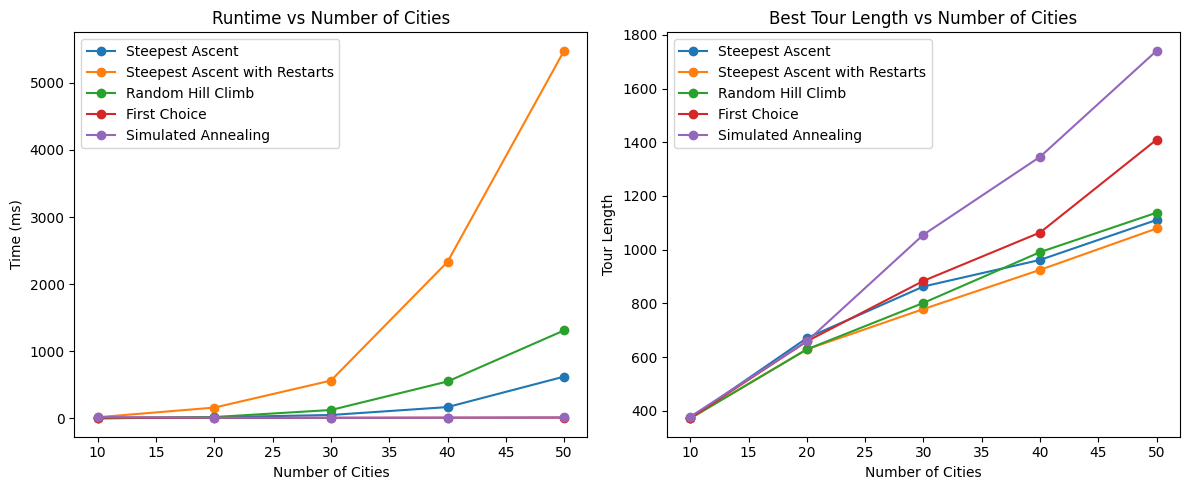

In [22]:
# Code and results go here
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Các thuật toán cần so sánh
algorithms = {
    "Steepest Ascent": lambda tsp: steepest_ascent_tsp(tsp, max_iter=1000),
    "Steepest Ascent with Restarts": lambda tsp: steepest_ascent_tsp_with_restarts(tsp, max_iter=1000, num_restarts=10),
    "Random Hill Climb": lambda tsp: random_hill_climb_tsp(tsp, max_iter=1000),
    "First Choice": lambda tsp: first_choice_hill_climb_tsp(tsp, max_iter=1000),
    "Simulated Annealing": lambda tsp: simulated_annealing_tsp(tsp, initial_temp=1000, cooling_rate=0.995, max_iter=1000)
}

# Kích thước các board (số thành phố)
city_sizes = [10, 20, 30, 40, 50]

# Lưu kết quả
results = []

# Chạy thử nghiệm
for n in city_sizes:
    print(f"\n=== Testing with {n} cities ===")
    dist_matrix = np.random.randint(10, 100, size=(n, n))
    dist_matrix = (dist_matrix + dist_matrix.T) // 2  # làm đối xứng
    np.fill_diagonal(dist_matrix, 0)
    tsp = {"dist": dist_matrix}

    for name, algo in algorithms.items():
        t0 = time.time()
        best_tour, best_length = algo(tsp)
        t1 = time.time()
        elapsed_ms = (t1 - t0) * 1e3

        results.append({
            "Algorithm": name,
            "Cities": n,
            "Tour Length": round(best_length, 2),
            "Runtime (ms)": round(elapsed_ms, 2)
        })

        print(f"{name}: Length = {best_length:.2f}, Time = {elapsed_ms:.2f} ms")

# Chuyển sang bảng
df = pd.DataFrame(results)
df = df.sort_values(by=["Cities", "Algorithm"])
print("\n📊 Bảng kết quả tổng hợp:")
print(df)

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

# Runtime
plt.subplot(1, 2, 1)
for name in algorithms:
    subset = df[df["Algorithm"] == name]
    plt.plot(subset["Cities"], subset["Runtime (ms)"], label=name, marker='o')
plt.title("Runtime vs Number of Cities")
plt.xlabel("Number of Cities")
plt.ylabel("Time (ms)")
plt.legend()

# Tour length
plt.subplot(1, 2, 2)
for name in algorithms:
    subset = df[df["Algorithm"] == name]
    plt.plot(subset["Cities"], subset["Tour Length"], label=name, marker='o')
plt.title("Best Tour Length vs Number of Cities")
plt.xlabel("Number of Cities")
plt.ylabel("Tour Length")
plt.legend()

plt.tight_layout()
plt.show()


## Bonus: Genetic Algorithm [+1 Point]

In [19]:
# Code goes here
import random
import time

def genetic_algorithm_tsp(tsp, population_size=100, generations=500, mutation_rate=0.02):
    n = tsp["dist"].shape[0]

    # Khởi tạo quần thể ban đầu
    population = [random_tour(n) for _ in range(population_size)]
    fitness = [tour_length(tsp, tour) for tour in population]

    best_tour = population[fitness.index(min(fitness))]
    best_length = min(fitness)

    for gen in range(generations):
        # Chọn lọc: chọn 50% cá thể tốt nhất
        sorted_population = [tour for _, tour in sorted(zip(fitness, population))]
        selected = sorted_population[:population_size // 2]

        # Lai ghép: tạo thế hệ mới bằng crossover
        offspring = []
        while len(offspring) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child = ordered_crossover(parent1, parent2)
            # Đột biến
            if random.random() < mutation_rate:
                mutate(child)
            offspring.append(child)

        population = offspring
        fitness = [tour_length(tsp, tour) for tour in population]

        # Cập nhật lời giải tốt nhất
        current_best_length = min(fitness)
        if current_best_length < best_length:
            best_length = current_best_length
            best_tour = population[fitness.index(current_best_length)]

    return best_tour, best_length

# Hàm crossover: Ordered Crossover (OX)
def ordered_crossover(parent1, parent2):
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[start:end+1] = parent1[start:end+1]

    fill_pos = (end + 1) % size
    for city in parent2:
        if city not in child:
            child[fill_pos] = city
            fill_pos = (fill_pos + 1) % size
    return child

# Hàm đột biến: đảo ngược đoạn ngẫu nhiên
def mutate(tour):
    i, j = sorted(random.sample(range(len(tour)), 2))
    tour[i:j+1] = reversed(tour[i:j+1])

# Benchmark và in kết quả
start_time = time.time()
best_tour, best_length = genetic_algorithm_tsp(tsp, population_size=100, generations=500, mutation_rate=0.02)
end_time = time.time()

print("Best tour found:", best_tour)
print("Tour length:", best_length)
print("Execution time: {:.4f} seconds".format(end_time - start_time))


Best tour found: [8, 35, 43, 37, 16, 17, 11, 2, 14, 41, 49, 0, 48, 44, 40, 46, 3, 34, 23, 1, 47, 20, 36, 12, 7, 38, 32, 6, 5, 45, 26, 27, 9, 42, 18, 30, 33, 39, 24, 4, 13, 19, 25, 29, 15, 31, 22, 21, 28, 10]
Tour length: 1569
Execution time: 1.9285 seconds
